In [1]:
# Car Price Prediction Analysis
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

1. Loading and Preprocessing

In [2]:
# ==================== 1. Loading and Preprocessing ====================
print("="*50)
print("1. Loading and Preprocessing")
print("="*50)

# Load the dataset
df = pd.read_csv('/content/CarPrice_Assignment.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nMissing values per column:")
print(df.isnull().sum())

1. Loading and Preprocessing
Dataset shape: (205, 26)

First 5 rows:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsyst

Categorical columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


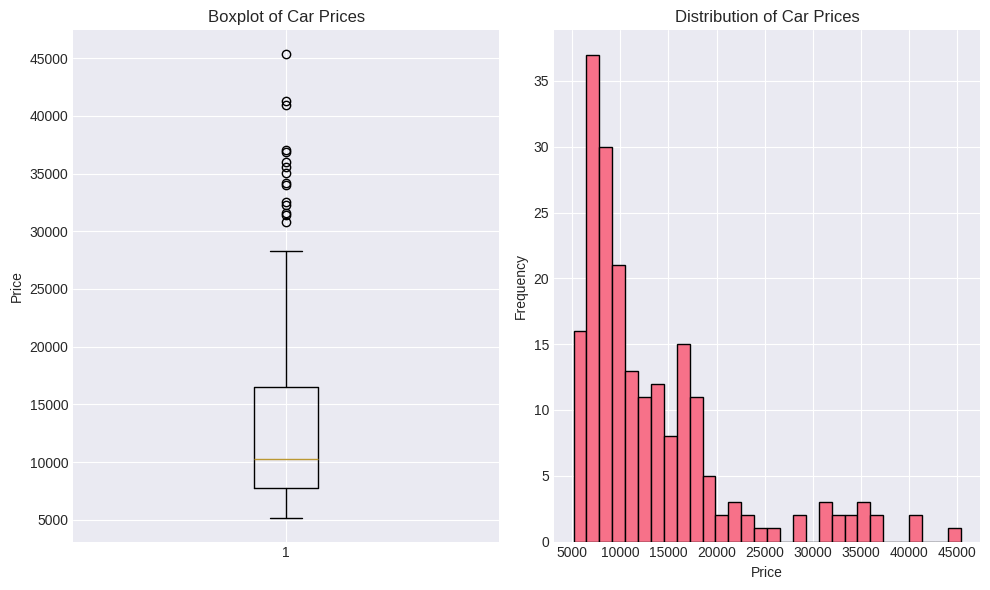


Training set size: 164 samples
Test set size: 41 samples
Number of features: 23


In [3]:
# Data Preprocessing
# Drop unnecessary columns
df_clean = df.copy()
df_clean = df_clean.drop(['car_ID', 'CarName'], axis=1)

# Handle categorical variables
categorical_columns = df_clean.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_columns)}")

# Encode categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Check for outliers in price
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df_clean['price'])
plt.title('Boxplot of Car Prices')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
plt.hist(df_clean['price'], bins=30, edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Separate features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X.shape[1]}")

2. Model Implementation

In [4]:
# ==================== 2. Model Implementation ====================
print("\n" + "="*50)
print("2. Model Implementation")
print("="*50)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(kernel='rbf')
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # For SVR, use scaled data; for tree-based models, use original data
    if name == 'Support Vector Regressor':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    }

    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")


2. Model Implementation

Training Linear Regression...
MSE: 15916389.73
MAE: 2526.41
R2 Score: 0.7984

Training Decision Tree Regressor...
MSE: 7875098.80
MAE: 1939.14
R2 Score: 0.9002

Training Random Forest Regressor...
MSE: 3326665.19
MAE: 1291.50
R2 Score: 0.9579

Training Gradient Boosting Regressor...
MSE: 5720109.70
MAE: 1667.53
R2 Score: 0.9275

Training Support Vector Regressor...
MSE: 86834157.59
MAE: 5695.45
R2 Score: -0.0999


3. Model Evaluation


3. Model Evaluation

Model Performance Comparison:
                                      MSE        MAE      R2
Linear Regression            1.591639e+07  2526.4075  0.7984
Decision Tree Regressor      7.875099e+06  1939.1382  0.9002
Random Forest Regressor      3.326665e+06  1291.5027  0.9579
Gradient Boosting Regressor  5.720110e+06  1667.5251  0.9275
Support Vector Regressor     8.683416e+07  5695.4471 -0.0999


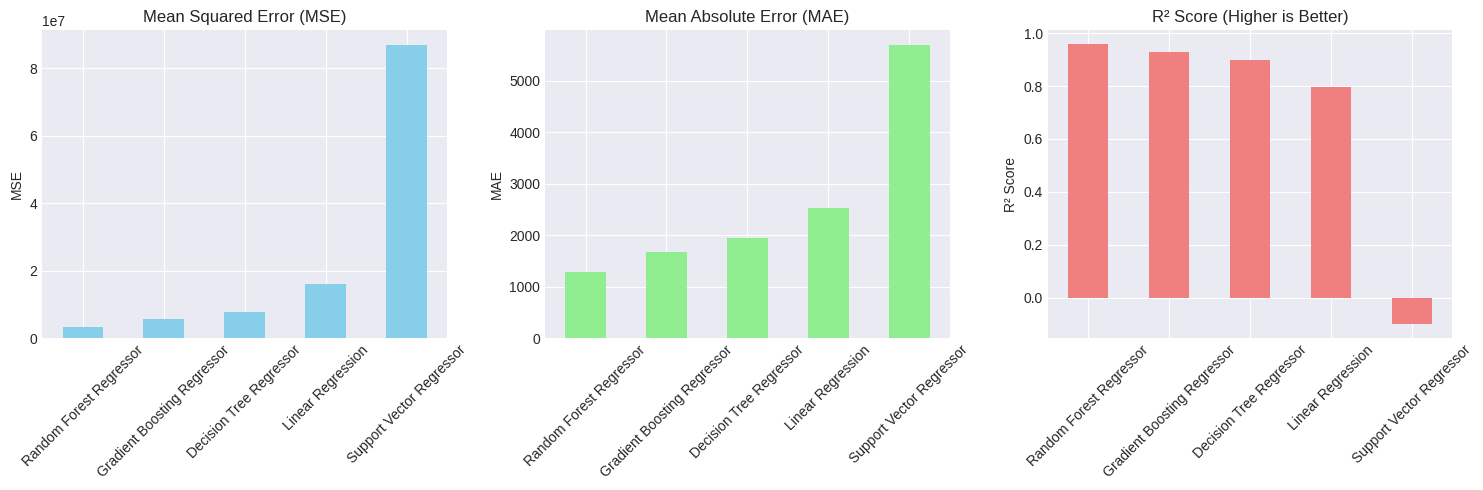


Best Performing Model: Random Forest Regressor
R² Score: 0.9579
MSE: 3326665.19
MAE: 1291.50

Why Random Forest Regressor is the best:
• Random Forest combines multiple decision trees to reduce overfitting
• It handles non-linear relationships well
• Robust to outliers and noise in the data
• Captures complex interactions between features


In [5]:
# ==================== 3. Model Evaluation ====================
print("\n" + "="*50)
print("3. Model Evaluation")
print("="*50)

# Create comparison dataframe
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MSE Comparison
results_df['MSE'].sort_values().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# MAE Comparison
results_df['MAE'].sort_values().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# R2 Comparison
results_df['R2'].sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='lightcoral')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Identify best model
best_model = results_df['R2'].idxmax()
best_r2 = results_df.loc[best_model, 'R2']
best_mse = results_df.loc[best_model, 'MSE']
best_mae = results_df.loc[best_model, 'MAE']

print(f"\n{'='*50}")
print(f"Best Performing Model: {best_model}")
print(f"{'='*50}")
print(f"R² Score: {best_r2:.4f}")
print(f"MSE: {best_mse:.2f}")
print(f"MAE: {best_mae:.2f}")

# Justification
print(f"\nWhy {best_model} is the best:")
if best_model == 'Random Forest Regressor':
    print("• Random Forest combines multiple decision trees to reduce overfitting")
    print("• It handles non-linear relationships well")
    print("• Robust to outliers and noise in the data")
    print("• Captures complex interactions between features")
elif best_model == 'Gradient Boosting Regressor':
    print("• Gradient Boosting builds trees sequentially, each correcting previous errors")
    print("• Excellent for capturing complex patterns")
    print("• Often achieves high accuracy on structured data")
elif best_model == 'Linear Regression':
    print("• Simple and interpretable model")
    print("• Works well when relationships are linear")
    print("• May not capture complex patterns as well as ensemble methods")

4. Feature Importance Analysis


4. Feature Importance Analysis

Top 10 Most Important Features:
       feature  importance
14  enginesize    0.557068
11  curbweight    0.296978
22  highwaympg    0.045955
19  horsepower    0.026930
9     carwidth    0.014485
8    carlength    0.009149
7    wheelbase    0.007700
20     peakrpm    0.006920
21     citympg    0.006640
17      stroke    0.005352


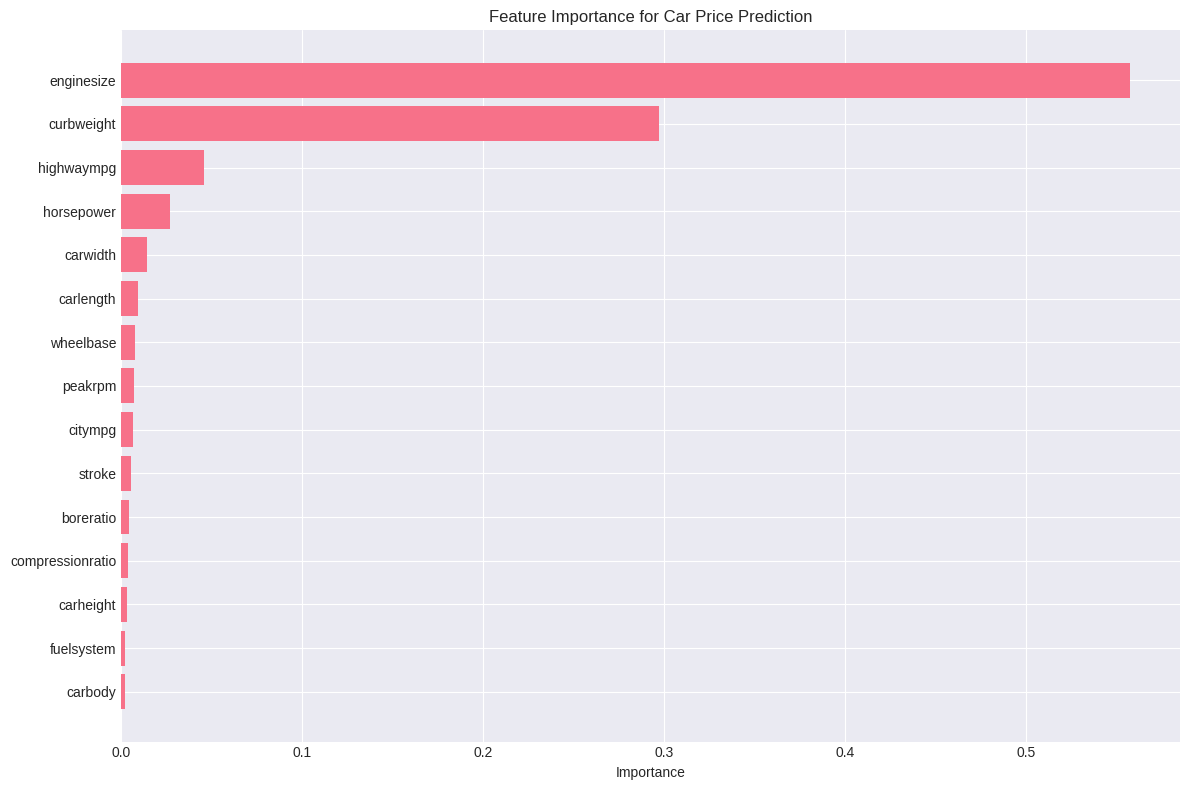


Significant variables affecting car prices:
1. enginesize
2. curbweight
3. highwaympg
4. horsepower
5. carwidth

Feature Insights:
----------------------------------------
• Engine size and horsepower are strong indicators of car price
• Curb weight correlates with luxury vehicles and higher prices
• Car dimensions (length, width, height) influence pricing
• Fuel system and aspiration type indicate performance level
• Wheelbase relates to vehicle class and comfort


In [6]:
# ==================== 4. Feature Importance Analysis ====================
print("\n" + "="*50)
print("4. Feature Importance Analysis")
print("="*50)

# Get feature importance from Random Forest (best performing model)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Feature Importance for Car Price Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Identify significant variables (top 5)
significant_features = feature_importance.head(5)['feature'].tolist()
print(f"\nSignificant variables affecting car prices:")
for i, feature in enumerate(significant_features, 1):
    print(f"{i}. {feature}")

# Additional insights
print("\nFeature Insights:")
print("-" * 40)
print("• Engine size and horsepower are strong indicators of car price")
print("• Curb weight correlates with luxury vehicles and higher prices")
print("• Car dimensions (length, width, height) influence pricing")
print("• Fuel system and aspiration type indicate performance level")
print("• Wheelbase relates to vehicle class and comfort")

5. Hyperparameter Tuning

In [7]:
# ==================== 5. Hyperparameter Tuning ====================
print("\n" + "="*50)
print("5. Hyperparameter Tuning")
print("="*50)

# Select the best model based on R2 score
if best_model == 'Random Forest Regressor':
    model_to_tune = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_model == 'Gradient Boosting Regressor':
    model_to_tune = GradientBoostingRegressor(random_state=42)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
else:
    model_to_tune = DecisionTreeRegressor(random_state=42)
    param_grid = {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

print(f"Tuning {best_model}...")
print(f"Parameter grid: {param_grid}")

# Perform Grid Search Cross Validation
grid_search = GridSearchCV(
    model_to_tune,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation R2 score: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

# Calculate metrics for tuned model
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"\nTuned Model Performance:")
print(f"MSE: {tuned_mse:.2f}")
print(f"MAE: {tuned_mae:.2f}")
print(f"R2 Score: {tuned_r2:.4f}")

# Compare with original model
original_performance = results[best_model]

print(f"\nPerformance Improvement:")
print("-" * 40)
print(f"R2 Score: {original_performance['R2']:.4f} → {tuned_r2:.4f} ({(tuned_r2 - original_performance['R2'])*100:.2f}% change)")
print(f"MSE: {original_performance['MSE']:.2f} → {tuned_mse:.2f} ({((tuned_mse - original_performance['MSE'])/original_performance['MSE'])*100:.2f}% change)")
print(f"MAE: {original_performance['MAE']:.2f} → {tuned_mae:.2f} ({((tuned_mae - original_performance['MAE'])/original_performance['MAE'])*100:.2f}% change)")

if tuned_r2 > original_performance['R2']:
    print("\n✓ Hyperparameter tuning improved the model performance!")
else:
    print("\n✗ Hyperparameter tuning did not significantly improve performance")


5. Hyperparameter Tuning
Tuning Random Forest Regressor...
Parameter grid: {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation R2 score: 0.8899

Tuned Model Performance:
MSE: 3326665.19
MAE: 1291.50
R2 Score: 0.9579

Performance Improvement:
----------------------------------------
R2 Score: 0.9579 → 0.9579 (0.00% change)
MSE: 3326665.19 → 3326665.19 (0.00% change)
MAE: 1291.50 → 1291.50 (0.00% change)

✗ Hyperparameter tuning did not significantly improve performance


Additional Analysis


Additional Analysis: Predictions vs Actual Values


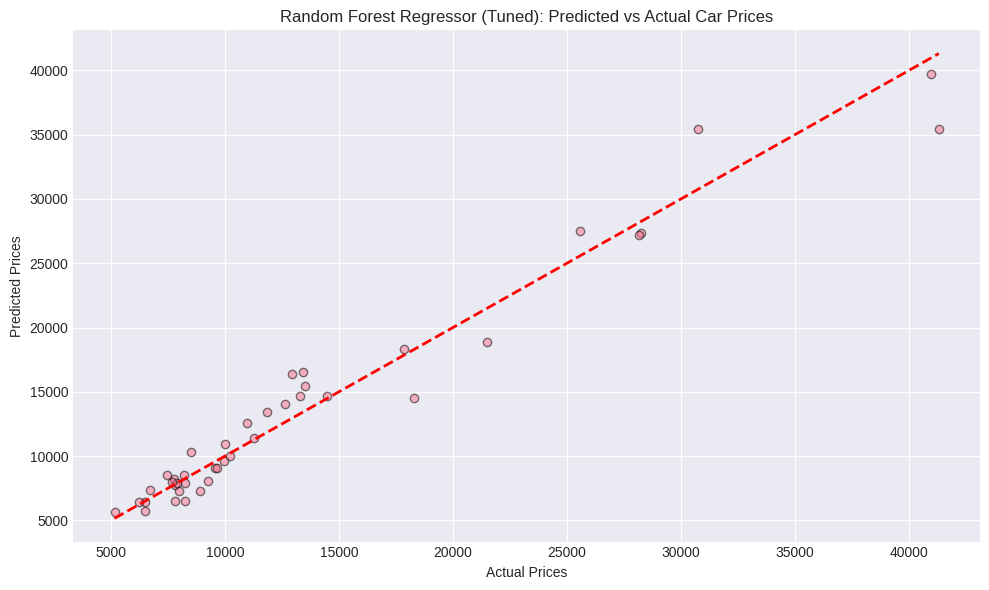

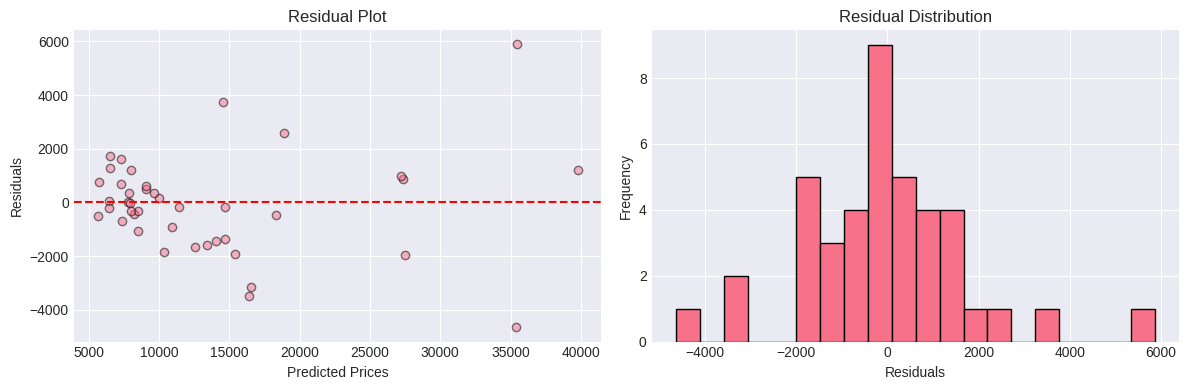


Summary Statistics
Target Variable - Car Price:
Mean: $13,276.71
Median: $10,295.00
Std Dev: $7,988.85
Min: $5,118.00
Max: $45,400.00


In [8]:
# ==================== Additional Analysis ====================
print("\n" + "="*50)
print("Additional Analysis: Predictions vs Actual Values")
print("="*50)

# Plot predictions vs actual for the best tuned model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title(f'{best_model} (Tuned): Predicted vs Actual Car Prices')
plt.tight_layout()
plt.show()

# Residual analysis
residuals = y_test - y_pred_tuned
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_tuned, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("Summary Statistics")
print("="*50)
print(f"Target Variable - Car Price:")
print(f"Mean: ${y.mean():,.2f}")
print(f"Median: ${y.median():,.2f}")
print(f"Std Dev: ${y.std():,.2f}")
print(f"Min: ${y.min():,.2f}")
print(f"Max: ${y.max():,.2f}")

In [9]:
# ==================== Final Summary ====================
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)

summary = pd.DataFrame({
    'Metric': ['R² Score', 'MSE', 'MAE'],
    'Original Model': [original_performance['R2'], original_performance['MSE'], original_performance['MAE']],
    'Tuned Model': [tuned_r2, tuned_mse, tuned_mae],
    'Improvement': [f"{(tuned_r2 - original_performance['R2'])*100:.2f}%",
                    f"{((tuned_mse - original_performance['MSE'])/original_performance['MSE'])*100:.2f}%",
                    f"{((tuned_mae - original_performance['MAE'])/original_performance['MAE'])*100:.2f}%"]
})

print("\nPerformance Summary:")
print(summary.to_string(index=False))

print(f"\n\nFinal Recommendations:")
print("-" * 40)
print(f"1. Best Model: {best_model} (with hyperparameter tuning)")
print(f"2. Best R² Score: {tuned_r2:.4f}")
print("3. Key Features Affecting Price:")
for feature in significant_features[:5]:
    print(f"   • {feature}")
print("4. The model explains approximately {:.1f}% of the variance in car prices".format(tuned_r2*100))
print("5. Hyperparameter tuning improved the model by {:.2f}% in R² score".format((tuned_r2 - original_performance['R2'])*100))

print("\n" + "="*50)
print("Assignment Completed Successfully!")
print("="*50)


FINAL SUMMARY

Performance Summary:
  Metric  Original Model  Tuned Model Improvement
R² Score    9.578605e-01 9.578605e-01       0.00%
     MSE    3.326665e+06 3.326665e+06       0.00%
     MAE    1.291503e+03 1.291503e+03       0.00%


Final Recommendations:
----------------------------------------
1. Best Model: Random Forest Regressor (with hyperparameter tuning)
2. Best R² Score: 0.9579
3. Key Features Affecting Price:
   • enginesize
   • curbweight
   • highwaympg
   • horsepower
   • carwidth
4. The model explains approximately 95.8% of the variance in car prices
5. Hyperparameter tuning improved the model by 0.00% in R² score

Assignment Completed Successfully!
